<a href="https://colab.research.google.com/github/ManasaRPatel/2025_ML/blob/main/kfold_.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [3]:
# (Optional) install extra libs if you need them (Colab has sklearn/pandas/plt normally)
# !pip install scikit-learn pandas matplotlib joblib --quiet

import numpy as np
import pandas as pd
from sklearn.datasets import load_iris, make_classification
from sklearn.model_selection import StratifiedKFold, cross_validate, GridSearchCV
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    confusion_matrix, classification_report
)
import joblib
import matplotlib.pyplot as plt

# reproducibility
RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

In [4]:
# Load a simple built-in dataset: Iris
data = load_iris()
X = data.data
y = data.target
feature_names = data.feature_names

# Make a DataFrame for clarity
df = pd.DataFrame(X, columns=feature_names)
df['target'] = y

print("Using Iris dataset. Classes:", np.unique(y))
display(df.head())

Using Iris dataset. Classes: [0 1 2]


,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),target
0,5.1,3.5,1.4,0.2,0
1,4.9,3.0,1.4,0.2,0
2,4.7,3.2,1.3,0.2,0
3,4.6,3.1,1.5,0.2,0
4,5.0,3.6,1.4,0.2,0


In [5]:
print("Shape:", df.shape)   # rows, cols
print("Target class counts:\n", df['target'].value_counts())
print("Any nulls?", df.isnull().any().any())


Shape: (150, 5)
Target class counts:
 target
0    50
1    50
2    50
Name: count, dtype: int64
Any nulls? False


In [6]:
# Prepare X, y
X = df.drop(columns=['target']).values
y = df['target'].values

k = 5
skf = StratifiedKFold(n_splits=k, shuffle=True, random_state=RANDOM_STATE)

pipeline = Pipeline([
    ('scaler', StandardScaler()),
    ('clf', LogisticRegression(max_iter=2000, solver='liblinear', random_state=RANDOM_STATE))
])

results = []
fold_no = 1

for train_idx, val_idx in skf.split(X, y):
    X_train, X_val = X[train_idx], X[val_idx]
    y_train, y_val = y[train_idx], y[val_idx]

    pipeline.fit(X_train, y_train)
    y_pred = pipeline.predict(X_val)

    acc = accuracy_score(y_val, y_pred)
    prec = precision_score(y_val, y_pred, average='macro')
    rec = recall_score(y_val, y_pred, average='macro')
    f1 = f1_score(y_val, y_pred, average='macro')

    print(f"\n--- Fold {fold_no} ---")
    print(f"Accuracy={acc:.4f}  Precision={prec:.4f}  Recall={rec:.4f}  F1={f1:.4f}")
    print("Confusion matrix:\n", confusion_matrix(y_val, y_pred))
    print("Classification report:\n", classification_report(y_val, y_pred))

    results.append({'fold': fold_no, 'accuracy': acc, 'precision': prec, 'recall': rec, 'f1': f1})
    fold_no += 1

res_df = pd.DataFrame(results)
print("\n=== Summary across folds ===")
print(res_df)
print("\nMean scores:\n", res_df.mean())



--- Fold 1 ---
Accuracy=0.9333  Precision=0.9444  Recall=0.9333  F1=0.9327
Confusion matrix:
 [[10  0  0]
 [ 0  8  2]
 [ 0  0 10]]
Classification report:
               precision    recall  f1-score   support

           0       1.00      1.00      1.00        10
           1       1.00      0.80      0.89        10
           2       0.83      1.00      0.91        10

    accuracy                           0.93        30
   macro avg       0.94      0.93      0.93        30
weighted avg       0.94      0.93      0.93        30


--- Fold 2 ---
Accuracy=0.9667  Precision=0.9697  Recall=0.9667  F1=0.9666
Confusion matrix:
 [[10  0  0]
 [ 0 10  0]
 [ 0  1  9]]
Classification report:
               precision    recall  f1-score   support

           0       1.00      1.00      1.00        10
           1       0.91      1.00      0.95        10
           2       1.00      0.90      0.95        10

    accuracy                           0.97        30
   macro avg       0.97      0.97  

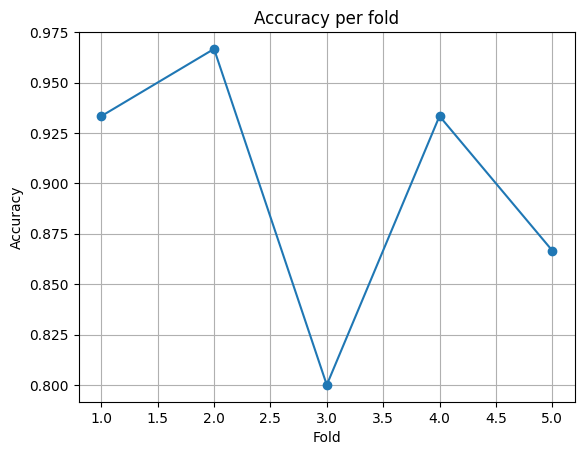

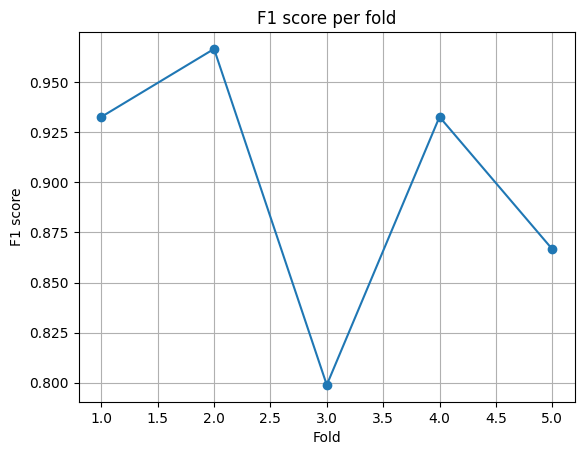

In [7]:
plt.plot(res_df['fold'], res_df['accuracy'], marker='o')
plt.title('Accuracy per fold')
plt.xlabel('Fold')
plt.ylabel('Accuracy')
plt.grid(True)
plt.show()

plt.plot(res_df['fold'], res_df['f1'], marker='o')
plt.title('F1 score per fold')
plt.xlabel('Fold')
plt.ylabel('F1 score')
plt.grid(True)
plt.show()